In [1]:
%matplotlib inline

import os
import glob
import pymzml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator, StrMethodFormatter
from pathlib import Path

# --- color for dominant features ---
dominant_color = "#000080"  # color for most abundant feature in fraction
background_bar_color = "#D9D2C7" # color for other features
chrom_color = "#000080"       # color for chromatogram
fluorescence_color = "#32CD32" # fluorescence
soft_edge_color = "#D9D2C7" # color of edges in feature abundance bar chart

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['svg.fonttype'] = 'none'


In [2]:
project_root = Path.cwd()

chrom_path = project_root / "data" / "004-D1M-B4-20250124_plant84_2.mzML" 
excel_path = project_root / "data" / "fractions_84_UV_clean.xlsx"       
big_csv = project_root / "data" / "big_feature_table_84.csv"         
frac_dir = project_root / "data" / "84"        
sample_name = "Macleaya microcarpa"                      

chrom_path2 = project_root / "data" / "004-D1M-B4-20250125_plant86_2.mzML"
excel_path2 = project_root / "data" / "fractions_86_UV_clean.xlsx"
big_csv2 = project_root / "data" / "big_feature_table_86.csv"
frac_dir2 = project_root / "data" / "86"
sample_name2 = "Macleaya cordata"

# tolerances / options (edit interactively)
mz_tol = 0.1
rt_tol = 1.0        # matches argparse default in original script; function default was 0.375
log_total_area = False


In [3]:
def plot_combined_sample(chrom_path, excel_path, big_csv, frac_dir,
                         sample_name, mz_tol=0.1, rt_tol=0.375,
                         height_ratio_top=1, height_ratio_bot=1,
                         log_total_area=False):
    # Read fraction definitions and compute mid/width
    df = pd.read_excel(excel_path)
    df['mid'] = (df['start'] + df['end']) / 2
    df['width'] = df['end'] - df['start']

    # Compute normalized fluorescence
    df['avg'] = df['average']
    pos = df['pos_avg'].iloc[0]
    df['norm_fluorescence'] = df['avg'] / pos
    df['norm_fluorescence_pct'] = df['norm_fluorescence'] / df['norm_fluorescence'].max() * 100

    # Load MS chromatogram times and intensities
    times, ints = [], []
    for spec in pymzml.run.Reader(chrom_path):
        t = spec.scan_time[0] if isinstance(spec.scan_time, tuple) else spec.scan_time
        peaks = spec.peaks('raw')
        if isinstance(t, (int, float)) and hasattr(peaks, '__len__') and len(peaks) > 0:
            times.append(float(t))
            ints.append(max(p[1] for p in peaks))
    times = np.array(times)
    ints = np.array(ints)

    # Identify target m/z and rt values
    big = pd.read_csv(big_csv)
    targets_mz = big['mz'].values  # keep as float array
    targets_rt = big['rt'].values  # keep as float array

    frac_files = sorted(glob.glob(str(frac_dir / "frac_*.csv")))


    stats = []
    matched_rows = []

    for idx, f in enumerate(frac_files[:len(df)]):
        try:
            sub = pd.read_csv(f)
        except pd.errors.EmptyDataError:
            stats.append({'sum': 0, 'max': 0, 'log': 0})
            continue

        if {'mz', 'rt', 'area'}.issubset(sub.columns):
            mz_values = sub['mz'].values
            rt_values = sub['rt'].values
            areas = sub['area'].values

            mask = np.array([
                np.any((np.abs(mz - targets_mz) <= mz_tol) &
                       (np.abs(rt - targets_rt) <= rt_tol))
                for mz, rt in zip(mz_values, rt_values)
            ])

            for mz_val, rt_val, area_val, keep in zip(mz_values, rt_values, areas, mask):
                if keep and area_val > 0:
                    matches = np.where((np.abs(mz_val - targets_mz) <= mz_tol) &
                                       (np.abs(rt_val - targets_rt) <= rt_tol))[0]
                    if matches.size > 0:
                        dists = (mz_val - targets_mz[matches]) ** 2 + (rt_val - targets_rt[matches]) ** 2
                        m = matches[np.argmin(dists)]
                        matched_rows.append({
                            'fraction_file': os.path.basename(f),
                            'fraction_index': idx,
                            'mz': mz_val,
                            'rt': rt_val,
                            'area': area_val,
                            'matched_target_mz': targets_mz[m],
                            'matched_target_rt': targets_rt[m]
                        })

            positive = areas[mask][areas[mask] > 0]
            total = positive.sum()
            maxi = positive.max() if positive.size > 0 else 0
            logv = np.log10(total) if (log_total_area and total > 0) else (total if not log_total_area else 0)

            stats.append({'sum': total, 'max': maxi, 'log': logv})
        else:
            stats.append({'sum': 0, 'max': 0, 'log': 0})

    if matched_rows:
        matched_df = pd.DataFrame(matched_rows)
        safe_name = sample_name.replace(' ', '_').replace('(', '').replace(')', '')
        out_csv = f"{safe_name}_matched_features.csv"
        matched_df.to_csv(out_csv, index=False)
        print(f"Saved matched features to {out_csv}")
    else:
        print("No matched features found (after applying mz+rt filter).")

    def plot_figure(ax1, ax2):
        ax12 = ax1.twinx()
        ax1.plot(times, ints, color=chrom_color, lw=1.5) #add chrom_color
        ax1.set_ylabel('MS intensity (BPC)') #, color=chrom_color)
        ax1.tick_params(axis='y') #, labelcolor=chrom_color)
        ax1.set_ylim(0, ints.max()*1.05 if ints.size else 1)

        ax12.bar(
            x=df['mid'], height=df['norm_fluorescence_pct'], width=df['width'],
            alpha=0.3, edgecolor='black', color=fluorescence_color
        )
        ax12.set_ylabel('Normalized fluorescence (%)') #, color=fluorescence_color)
        ax12.tick_params(axis='y') #, labelcolor=fluorescence_color)
        ax12.set_ylim(0, 100)
        ax12.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax12.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))

        ax1.set_title(f"{sample_name}{' (log10 total area proportion)' if log_total_area else ''}")
        ax1.spines['bottom'].set_visible(False)
        ax1.xaxis.set_ticks_position('none')

        max_bar = max(s['log'] if log_total_area else s['sum'] for s in stats) if stats else 1
        for j, s in enumerate(stats):
            mid = df['mid'].iloc[j]
            width = df['width'].iloc[j]
            if not log_total_area:
                red_h = s['max']
                grey_h = s['sum'] - red_h
                ax2.bar(mid, red_h, width=width, color=dominant_color, edgecolor=background_bar_color)
                if grey_h > 0:
                    ax2.bar(mid, grey_h, bottom=red_h, width=width, color=background_bar_color, edgecolor="none")
            else:
                total_log = s['log']
                prop = s['max'] / s['sum'] if s['sum'] > 0 else 0
                red_h = total_log * prop
                grey_h = total_log - red_h
                ax2.bar(mid, red_h, width=width, color=dominant_color, edgecolor=background_bar_color)
                if grey_h > 0:
                    ax2.bar(mid, grey_h, bottom=red_h, width=width, color=background_bar_color, edgecolor="none")

        ax2.set_ylim(1.5, max_bar * 1.05)
        ax2.invert_yaxis()
        ax2.set_ylabel('Feature area' if not log_total_area else 'log10(total area)')
        ax2.spines['top'].set_visible(False)

        ax2.set_xlabel('Retention time [min]')
        tmax = max(times.max() if times.size else 0, df['mid'].max() if not df['mid'].empty else 0)
        ticks = np.arange(0, int(np.floor(tmax/5)*5)+1, 5)
        ax2.set_xticks(ticks)
        ax2.set_xticklabels([str(int(t)) for t in ticks], rotation=90, fontsize=8)

    fig, (ax1a, ax2a) = plt.subplots(2, 1, sharex=True, figsize=(14, 8),
                                 gridspec_kw={'height_ratios': [height_ratio_top, height_ratio_bot], 'hspace': 0})
    fig.subplots_adjust(hspace=-0.05, right=0.95)
    plot_figure(ax1a, ax2a)

# limit x-range to 0–38 min on both subplots
    ax1a.set_xlim(0, 38)
    ax2a.set_xlim(0, 38)

# use 5-min ticks within that window
    ticks = np.arange(0, 39, 5)
    ax2a.set_xticks(ticks)
    ax2a.set_xticklabels([str(int(t)) for t in ticks], rotation=90, fontsize=8)

    suffix = '_log' if log_total_area else ''
    fig.savefig(
        f"{sample_name.replace(' ', '_').replace('(', '').replace(')', '')}{suffix}.svg",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()



Saved matched features to Macleaya_microcarpa_matched_features.csv


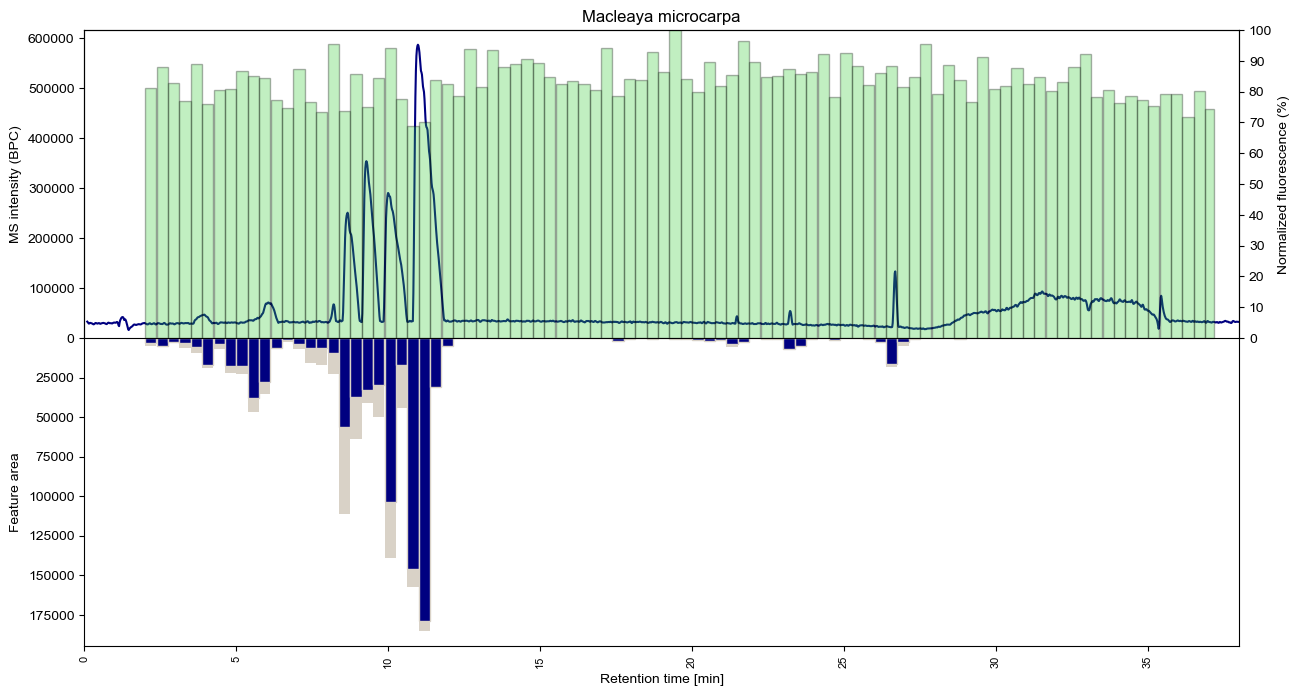

Saved matched features to Macleaya_cordata_matched_features.csv


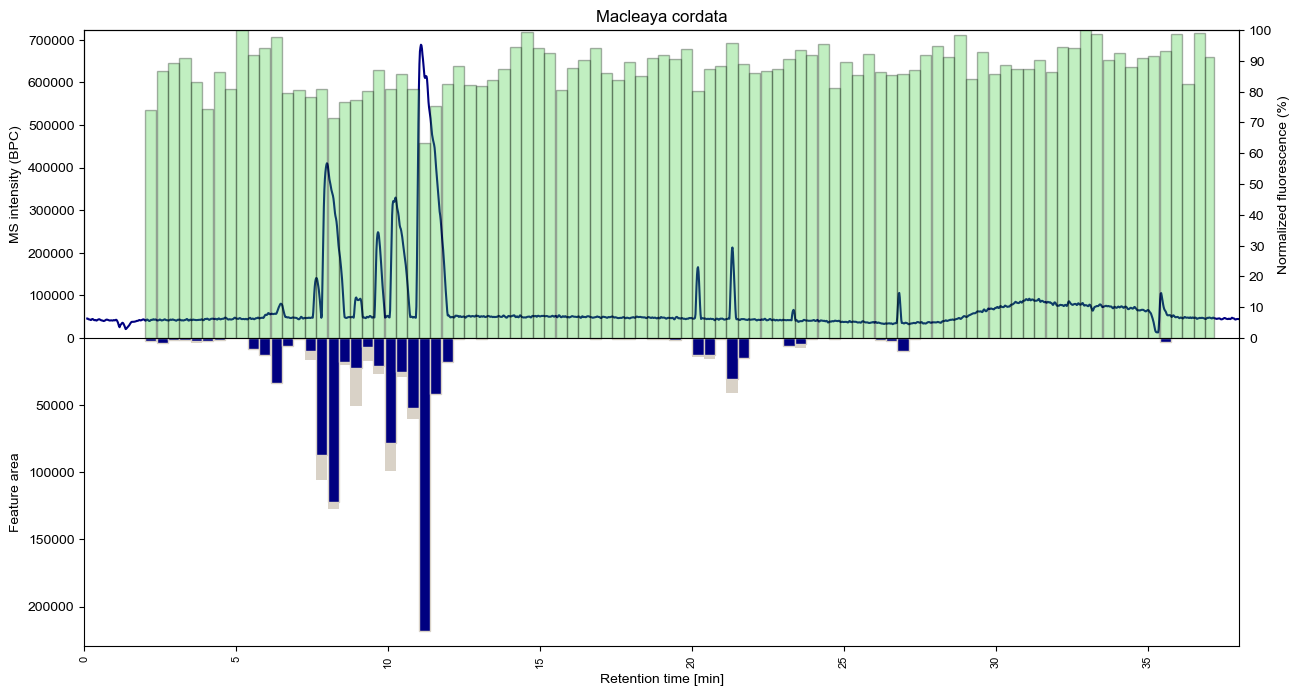

In [4]:
# Example run (uncomment to execute):
for (chrom_i, excel_i, big_i, frac_i, name_i) in [
    (chrom_path,  excel_path,  big_csv,  frac_dir,  sample_name),   # sample 1
    (chrom_path2, excel_path2, big_csv2, frac_dir2, sample_name2),  # sample 2
]:
    plot_combined_sample(
        chrom_i, excel_i, big_i, frac_i, name_i,
        mz_tol=mz_tol, rt_tol=rt_tol, log_total_area=log_total_area,
    )
